À propos de Dataset
Le jeu de données Social Media Sentiments Analysis Dataset capture une tapisserie vibrante d’émotions, de tendances et d’interactions à travers diverses plateformes sociales. Ce jeu de données offre un instantané du contenu généré par les utilisateurs, comprenant texte, horodatages, hashtags, pays, likes et retweets. Chaque entrée dévoile des histoires uniques — des moments de surprise, d’excitation, d’admiration, de sensation forte, de contentement, et bien plus encore — partagés par des individus du monde entier.

# 1 - Exploration

In [38]:
import pandas as pd

In [39]:
df = pd.read_csv("sentimentdataset.csv")
df.head(3)

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15


In [40]:
df = df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])

In [41]:
df.columns

Index(['Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags',
       'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour'],
      dtype='object')

- Text  : Contenu généré par les utilisateurs mettant en avant les sentiments
- Sentiment : Émotions catégorisées
- Timestamp : Informations sur la date et l’heure
- User : Identifiants uniques des utilisateurs contribuant
- Platform : Plateforme de réseaux sociaux d’où provient le contenu
- Hashtags : Identifie les sujets et thèmes en vogue
- Retweets : Quantifie l’engagement des utilisateurs (likes)
- Likes : Reflète la popularité du contenu (retweets)
- Country : Origine géographique de chaque poste
- Year : Année du poste
- Month : Mois du poste
- Day : Jour de la publication
- Hour : 	Heure du billet

In [42]:
df.shape

(732, 13)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Text       732 non-null    object 
 1   Sentiment  732 non-null    object 
 2   Timestamp  732 non-null    object 
 3   User       732 non-null    object 
 4   Platform   732 non-null    object 
 5   Hashtags   732 non-null    object 
 6   Retweets   732 non-null    float64
 7   Likes      732 non-null    float64
 8   Country    732 non-null    object 
 9   Year       732 non-null    int64  
 10  Month      732 non-null    int64  
 11  Day        732 non-null    int64  
 12  Hour       732 non-null    int64  
dtypes: float64(2), int64(4), object(7)
memory usage: 74.5+ KB


In [44]:
df.isna().sum()

Text         0
Sentiment    0
Timestamp    0
User         0
Platform     0
Hashtags     0
Retweets     0
Likes        0
Country      0
Year         0
Month        0
Day          0
Hour         0
dtype: int64

In [45]:
df.describe(include="object")

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Country
count,732,732,732,732,732,732,732
unique,707,279,683,685,4,697,115
top,"A compassionate rain, tears of empathy fallin...",Positive,2020-01-05 08:45:00,RainNurturer,Instagram,#Compassionate #TearsOfEmpathy,USA
freq,3,44,3,3,258,3,59


In [46]:
df['Sentiment'].value_counts()

Sentiment
Positive               44
Joy                    42
Excitement             32
Happy                  14
Neutral                14
                       ..
Vibrancy                1
Culinary Adventure      1
Mesmerizing             1
Thrilling Journey       1
Winter Magic            1
Name: count, Length: 279, dtype: int64

In [47]:
print(df['Sentiment'].value_counts(dropna=False))

print(" Aperçu de 3 textes ")
for i, text in enumerate(df['Text'].head(3), 1):
    print(f"{i}. {text}")

Sentiment
Positive               44
Joy                    42
Excitement             32
Happy                  14
Neutral                14
                       ..
Vibrancy                1
Culinary Adventure      1
Mesmerizing             1
Thrilling Journey       1
Winter Magic            1
Name: count, Length: 279, dtype: int64
 Aperçu de 3 textes 
1.  Enjoying a beautiful day at the park!              
2.  Traffic was terrible this morning.                 
3.  Just finished an amazing workout! 💪               


# 2- Nettoyage et Préparation des Données

In [48]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Supprimer les URLs (http, https, www)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # 2. Supprimer les mentions (@utilisateur)
    text = re.sub(r'@\w+', '', text)
    
    # 3. Supprimer les caractères spéciaux inutiles et ponctuations répétées (garder lettres, chiffres, émojis)
    # Conservation des hashtags pour l'instant (ex: #super -> super)
    text = re.sub(r'#(\w+)', r'\1', text)
    
    # 4. Supprimer les espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Application du nettoyage
df['Clean_Text'] = df['Text'].apply(clean_text)

# Vérification : Comparaison avant et après sur 3 exemples
for i in range(min(5, len(df))):
    print(f"--- POST {i+1} ---")
    print(f"BRUT    : {df['Text'].iloc[i]}")
    print(f"NETTOYÉ : {df['Clean_Text'].iloc[i]}\n")

--- POST 1 ---
BRUT    :  Enjoying a beautiful day at the park!              
NETTOYÉ : Enjoying a beautiful day at the park!

--- POST 2 ---
BRUT    :  Traffic was terrible this morning.                 
NETTOYÉ : Traffic was terrible this morning.

--- POST 3 ---
BRUT    :  Just finished an amazing workout! 💪               
NETTOYÉ : Just finished an amazing workout! 💪

--- POST 4 ---
BRUT    :  Excited about the upcoming weekend getaway!        
NETTOYÉ : Excited about the upcoming weekend getaway!

--- POST 5 ---
BRUT    :  Trying out a new recipe for dinner tonight.        
NETTOYÉ : Trying out a new recipe for dinner tonight.



In [49]:
df.head(3)

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,Clean_Text
0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12,Enjoying a beautiful day at the park!
1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8,Traffic was terrible this morning.
2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15,Just finished an amazing workout! 💪


# 3 - Prédiction automatique avec Hugging Face

In [51]:
from transformers import pipeline
from tqdm import tqdm

# 1. Charger le pipeline de classification de sentiments pré-entraîné pour les réseaux sociaux
print("Chargement du modèle NLP...")
sentiment_pipeline = pipeline(
    "text-classification", 
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    tokenizer="cardiffnlp/twitter-roberta-base-sentiment-latest", #facultatif
    truncation=True,
    max_length=512,
    device=-1  # utilisation du CPU
)

# 2. Préparation des textes
texts = df['Clean_Text'].fillna("").tolist()

# 3. Prédiction par lots (batches) pour accélérer le traitement
batch_size = 32  # Taille du lot
results = []

print("Analyse des sentiments en cours...")
for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i:i + batch_size]
    # Remplacer les chaînes vides temporairement pour éviter les erreurs du modèle
    batch_clean = [t if len(t.strip()) > 0 else "neutral" for t in batch]
    predictions = sentiment_pipeline(batch_clean)
    results.extend(predictions)

# 4. Stocker les résultats dans le DataFrame
df['Predicted_Sentiment'] = [res['label'] for res in results]
df['Sentiment_Score'] = [res['score'] for res in results]  # Niveau de confiance du modèle (0 à 1)

# 5. Afficher la distribution des sentiments
print("\Répartition des sentiments prédits")
print(df['Predicted_Sentiment'].value_counts())

# Aperçu de quelques prédictions
df[['Clean_Text', 'Predicted_Sentiment', 'Sentiment_Score']].head()

Chargement du modèle NLP...


<>:35: SyntaxWarning: invalid escape sequence '\R'
<>:35: SyntaxWarning: invalid escape sequence '\R'
C:\Users\D C\AppData\Local\Temp\ipykernel_25780\527660822.py:35: SyntaxWarning: invalid escape sequence '\R'
  print("\Répartition des sentiments prédits")
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7720.50it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Analyse des sentiments en cours...


100%|██████████| 23/23 [01:21<00:00,  3.55s/it]

\Répartition des sentiments prédits
Predicted_Sentiment
positive    458
negative    172
neutral     102
Name: count, dtype: int64


,Clean_Text,Predicted_Sentiment,Sentiment_Score
0,Enjoying a beautiful day at the park!,positive,0.983226
1,Traffic was terrible this morning.,negative,0.945377
2,Just finished an amazing workout! 💪,positive,0.980885
3,Excited about the upcoming weekend getaway!,positive,0.986628
4,Trying out a new recipe for dinner tonight.,neutral,0.732569


In [52]:
# 1. Taux de satisfaction global (%)
satisfaction_rate = (df['Predicted_Sentiment'] == 'positive').mean() * 100
print(f"Taux de posts positifs : {satisfaction_rate:.2f}%")

# 2. Analyse croisée : Sentiment par Plateforme
print("\n--- Répartition des sentiments par Plateforme ---")
# 1. Supprimer les espaces en début/fin et tout mettre en majuscules
df['Platform'] = df['Platform'].astype(str).str.strip().str.capitalize()
print(pd.crosstab(df['Platform'], df['Predicted_Sentiment'], normalize='index') * 100)

# 3. Engagement moyen (Likes / Retweets) selon le sentiment
print("\n--- Engagement moyen par type de sentiment ---")
print(df.groupby('Predicted_Sentiment')[['Likes', 'Retweets']].mean())

Taux de posts positifs : 62.57%

--- Répartition des sentiments par Plateforme ---
Predicted_Sentiment   negative    neutral   positive
Platform                                            
Facebook             24.242424  12.121212  63.636364
Instagram            21.317829  14.341085  64.341085
Twitter              25.102881  15.226337  59.670782

--- Engagement moyen par type de sentiment ---
                         Likes   Retweets
Predicted_Sentiment                      
negative             35.034884  17.552326
neutral              41.450980  20.745098
positive             46.179039  23.163755


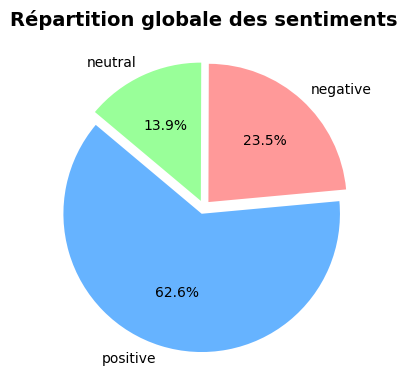

In [53]:
import matplotlib.pyplot as plt

# 1. Compter les occurrences de chaque sentiment
sentiment_counts = df['Predicted_Sentiment'].value_counts()

# 2. Définir des couleurs adaptées (Rouge pour négatif, Gris/Bleu pour neutre, Vert pour positif)
colors = {'positive': '#66b3ff', 'neutral': '#99ff99', 'negative': '#ff9999'}
palette = [colors.get(x, '#c2c2f0') for x in sentiment_counts.index]

# 3. Créer le Pie Chart
plt.figure(figsize=(4, 4))
plt.pie(
    sentiment_counts, 
    labels=sentiment_counts.index, 
    autopct='%1.1f%%',  # Affiche le pourcentage avec 1 décimale
    startangle=140, 
    colors=palette,
    explode=[0.05] * len(sentiment_counts)  # Détache légèrement les parts
)

plt.title('Répartition globale des sentiments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

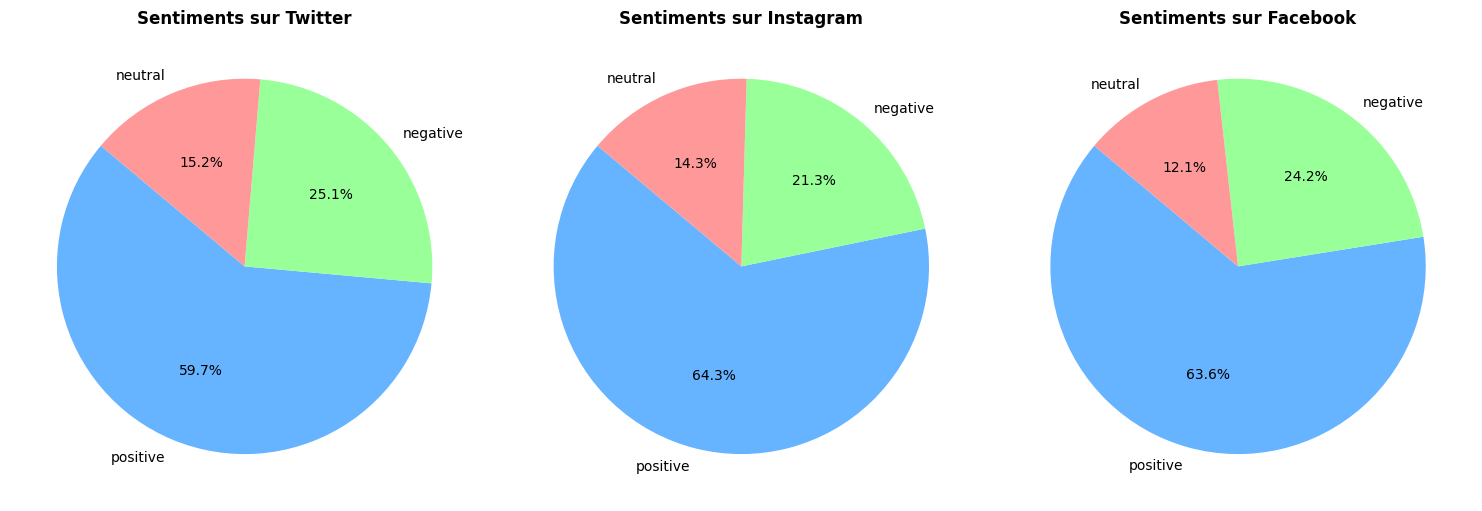

In [54]:
import matplotlib.pyplot as plt

# 1. Obtenir la liste des plateformes uniques
platforms = df['Platform'].unique()

# 2. Créer une grille de sous-graphiques (1 ligne, N colonnes)
fig, axes = plt.subplots(1, len(platforms), figsize=(5 * len(platforms), 5))

# 3. Générer un camembert pour chaque réseau social
for ax, platform in zip(axes, platforms):
    data = df[df['Platform'] == platform]['Predicted_Sentiment'].value_counts()
    
    ax.pie(
        data, 
        labels=data.index, 
        autopct='%1.1f%%', 
        startangle=140,
        colors=['#66b3ff', '#99ff99', '#ff9999']
    )
    ax.set_title(f'Sentiments sur {platform}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [56]:
%pip install nltk

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 4.7 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from collections import Counter
import nltk
from nltk.corpus import stopwords

# Télécharger les mots
nltk.download('stopwords')

# Combiner les mots vides 
stop_words = set(stopwords.words('english')).union(set(stopwords.words('french')))

def afficher_top_mots_par_sentiment(df, col_texte='Clean_Text', col_sentiment='Predicted_Sentiment', top_n=10):
    """
    Affiche les mots les plus fréquents pour chaque classe de sentiment.
    """
    for sentiment in df[col_sentiment].unique():
        # 1. Filtrer les textes du sentiment
        textes = df[df[col_sentiment] == sentiment][col_texte]
        
        # 2. Extraire et nettoyer les mots
        tous_les_mots = []
        for texte in textes:
            mots = str(texte).lower().split()
            # On garde les mots de plus de 2 lettres qui ne sont pas des stopwords
            mots_filtres = [m for m in mots if m.isalnum() and m not in stop_words and len(m) > 2]
            tous_les_mots.extend(mots_filtres)
            
        # 3. Compter les occurrences
        top_mots = Counter(tous_les_mots).most_common(top_n)
        
        # 4. Afficher sous forme de DataFrame propre
        print(f"\n TOP {top_n} MOTS POUR LE SENTIMENT : {sentiment.upper()}")
        print(pd.DataFrame(top_mots, columns=['Mot', 'Fréquence']))

# Exécution du script sur votre DataFrame
afficher_top_mots_par_sentiment(df)

[nltk_data] Downloading package stopwords to C:\Users\D
[nltk_data]     C\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.



 TOP 10 MOTS POUR LE SENTIMENT : POSITIVE
          Mot  Fréquence
0         new         37
1      beauty         20
2    laughter         17
3     feeling         15
4         art         15
5       every         14
6   exploring         13
7       dance         13
8     finding         12
9  excitement         12

 TOP 10 MOTS POUR LE SENTIMENT : NEGATIVE
         Mot  Fréquence
0       like         14
1  shattered         13
2       lost         11
3    feeling         10
4     echoes         10
5      heart          7
6        day          6
7     silent          6
8  labyrinth          6
9     broken          6

 TOP 10 MOTS POUR LE SENTIMENT : NEUTRAL
          Mot  Fréquence
0         new          6
1         old          6
2     journey          6
3       tales          6
4   attending          5
5     elation          5
6    whispers          5
7   nostalgia          5
8      trying          4
9  reflecting          4


C:\Users\D C\AppData\Local\Temp\ipykernel_25780\2491721078.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\D C\AppData\Local\Temp\ipykernel_25780\2491721078.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\D C\AppData\Local\Temp\ipykernel_25780\2491721078.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


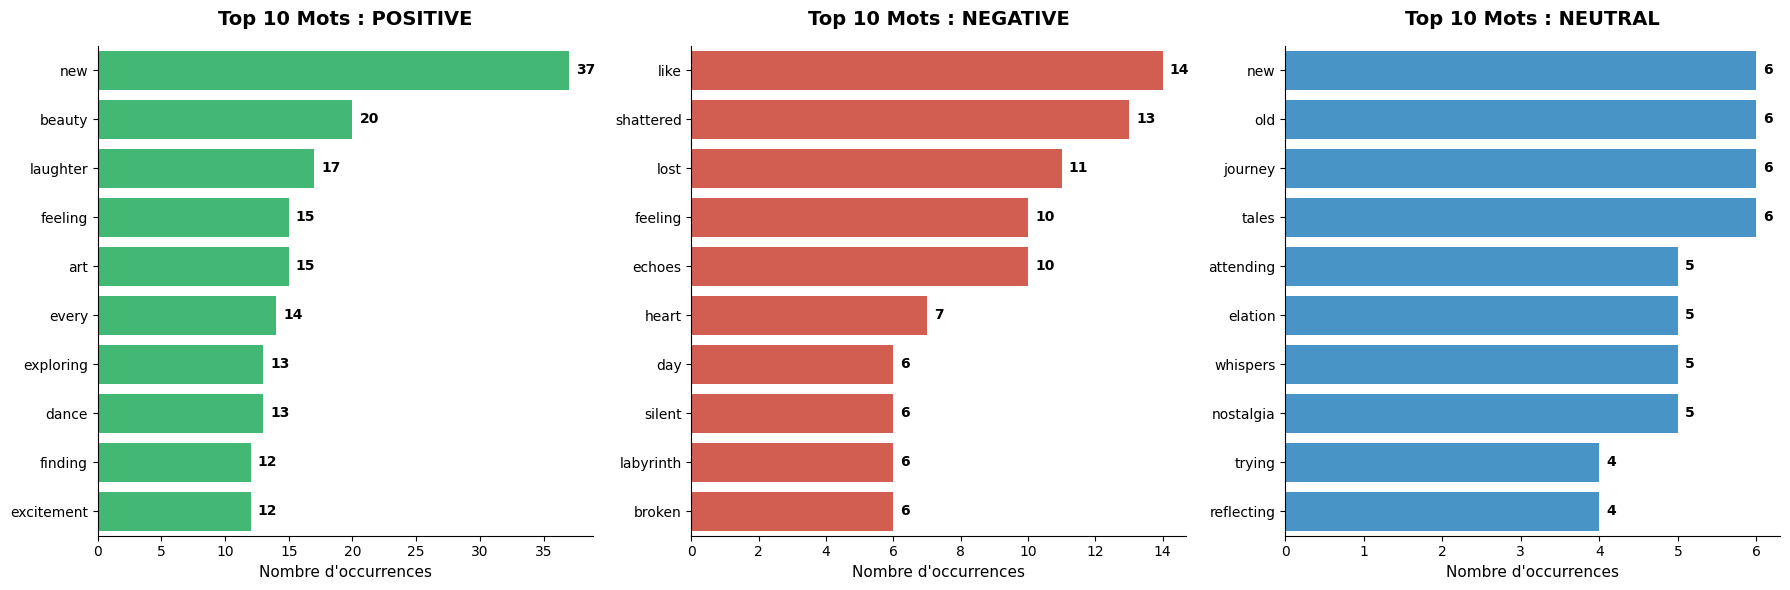

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter
from nltk.corpus import stopwords

# 1.  couleurs par sentiment (Rouge pour négatif, Bleu pour neutre, Vert pour positif)
couleurs = {
    'negative': '#e74c3c',
    'neutral': '#3498db',
    'positive': '#2ecc71'
}

# 2. Obtenir la liste des sentiments présents dans vos données
sentiments = df['Predicted_Sentiment'].unique()

# 3. Créer une figure avec autant de sous-graphiques que de sentiments (1 ligne, N colonnes)
fig, axes = plt.subplots(1, len(sentiments), figsize=(6 * len(sentiments), 6))



# 4. Boucle pour générer un graphique par sentiment
for ax, sentiment in zip(axes, sentiments):
    # Récupérer les 10 mots les plus fréquents pour ce sentiment
    textes = df[df['Predicted_Sentiment'] == sentiment]['Clean_Text']
    mots_list = []
    for t in textes:
        mots = [m.lower() for m in str(t).split() if m.isalnum() and m.lower() not in stop_words and len(m) > 2]
        mots_list.extend(mots)
    
    # Transformer les top mots en DataFrame pour Seaborn
    top_df = pd.DataFrame(Counter(mots_list).most_common(10), columns=['Mot', 'Fréquence'])
    
    # Couleur du graphique selon le sentiment (gris par défaut si inconnu)
    couleur = couleurs.get(sentiment.lower(), '#95a5a6')
    
    # Dessiner le graphique en barres horizontales
    sns.barplot(
        data=top_df, 
        x='Fréquence', 
        y='Mot', 
        ax=ax, 
        palette=[couleur] * len(top_df)
    )
    
    # Ajouter la valeur exacte au bout de chaque barre
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(
            f'{int(width)}', 
            (width, p.get_y() + p.get_height() / 2.),
            ha='left', va='center', 
            xytext=(5, 0), textcoords='offset points', 
            fontsize=10, fontweight='bold'
        )
    
    # Personnalisation des titres et axes
    ax.set_title(f'Top 10 Mots : {sentiment.upper()}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Nombre d\'occurrences', fontsize=11)
    ax.set_ylabel('')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

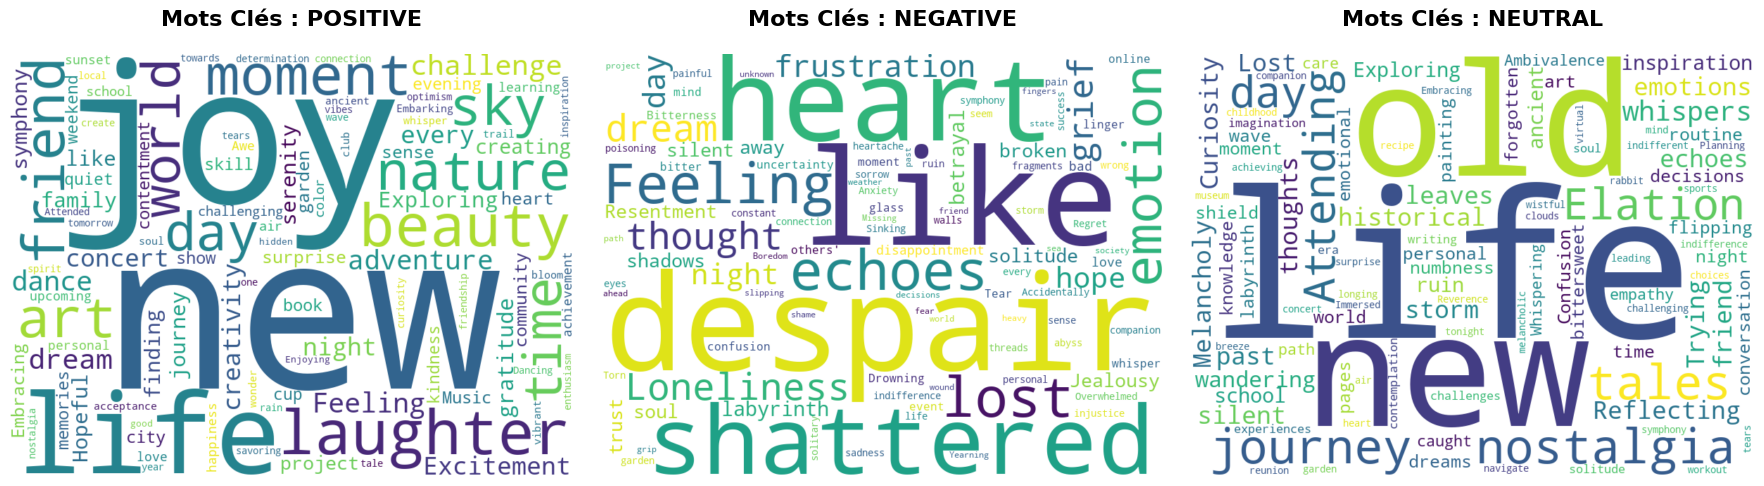

In [63]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd
from nltk.corpus import stopwords
import nltk

# S'assurer que les stopwords sont téléchargés
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# 1. Définition de la liste des mots inutiles (anglais + français)
stop_words_list = set(stopwords.words('english')).union(set(stopwords.words('french')))


# 2. Obtenir les sentiments uniques et configurer la grille
sentiments = df['Predicted_Sentiment'].unique()
fig, axes = plt.subplots(1, len(sentiments), figsize=(6 * len(sentiments), 7))


# 3. Boucle pour générer un WordCloud par sentiment
for ax, sentiment in zip(axes, sentiments):
    # 3a. Rassembler tout le texte de cette catégorie en une seule grande chaîne
    text_data = " ".join(df[df['Predicted_Sentiment'] == sentiment]['Clean_Text'].astype(str))
    
    if len(text_data.strip()) < 10: # Éviter les erreurs si pas assez de données
        ax.axis('off')
        ax.set_title(f'Pas assez de données pour : {sentiment.upper()}')
        continue

    # 3b. Configuration du WordCloud
    wc = WordCloud(
        background_color='white', # Fond blanc pour mieux voir les couleurs
        max_words=100,           # Limiter à 100 mots pour la lisibilité
        stopwords=stop_words_list,# Utiliser notre liste de mots inutiles
        width=800, 
        height=600,
        colormap='viridis',      # Palette de couleurs (ex: 'viridis', 'plasma', 'coolwarm')
        collocations=False       # Éviter de répéter des paires de mots (ex: "très bon" + "bon")
    ).generate(text_data)
    
    # 3c. Affichage sur le sous-graphique Matplotlib
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Mots Clés : {sentiment.upper()}', fontsize=16, fontweight='bold', pad=20)
    ax.axis('off') # Masquer les axes (coordonnées)

plt.tight_layout(pad=2)
plt.show()